# Module 2: Elliptic Curves

## 2.1 The Curve Equation

An elliptic curve over a field $\mathbb{F}$ is defined by the **Weierstrass equation**:

$$y^2 = x^3 + ax + b$$

with the constraint that $4a^3 + 27b^2 \neq 0$ (non-singular — no cusps or self-intersections).

### Bitcoin's curve: secp256k1

$$y^2 = x^3 + 7 \pmod{P}$$

where $a = 0$, $b = 7$ (a **Koblitz curve** — the zero $a$ enables optimizations).

### The generator point $G$

The curve has $\approx 2^{256}$ points on it. To use it for cryptography, everyone
needs to agree on a single **starting point** — a specific point $G$ on the curve
that's publicly known and hardcoded into every Bitcoin implementation.

Why? Because the one-way function is $P = d \times G$ — you pick a secret number
$d$ (your private key), multiply $G$ by $d$ using point addition, and get your
public key $P$. Everyone uses the **same** $G$, so anyone can verify your public
key and signatures.

$G$ is just a point $(x, y)$ on the curve. It was chosen as part of the secp256k1
standard — there's nothing mathematically special about it compared to other points,
but everyone must use the same one. It generates the entire group: $G, 2G, 3G,
\ldots, NG = \mathcal{O}$ cycles through all $N$ points and back to infinity.
That's why it's called the **generator** — every point on the curve is some
multiple of $G$.

In [1]:
# secp256k1 parameters — the numbers that secure Bitcoin

# Field prime: coordinates live in F_P
SECP_P = 0xFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFEFFFFFC2F

# Group order: scalars (private keys) live in Z_N  
SECP_N = 0xFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFFEBAAEDCE6AF48A03BBFD25E8CD0364141

# Generator point G: the "starting point" for all key generation
SECP_GX = 0x79BE667EF9DCBBAC55A06295CE870B07029BFCDB2DCE28D959F2815B16F81798
SECP_GY = 0x483ADA7726A3C4655DA4FBFC0E1108A8FD17B448A68554199C47D08FFB10D4B8

# Curve coefficients
A_COEFF = 0
B_COEFF = 7

print("=== secp256k1 Parameters ===")
print(f"Curve: y² = x³ + {A_COEFF}x + {B_COEFF}")
print(f"P = 2²⁵⁶ - 2³² - 977")
print(f"  = {SECP_P}")
print(f"  ({SECP_P.bit_length()} bits)")
print(f"\nN = {SECP_N}")
print(f"  ({SECP_N.bit_length()} bits)")
print(f"\nNon-singular check: 4(0)³ + 27(7)² = {4*0**3 + 27*7**2} ≠ 0  ✓")
print(f"\nP mod 4 = {SECP_P % 4}  (enables efficient square roots)")

=== secp256k1 Parameters ===
Curve: y² = x³ + 0x + 7
P = 2²⁵⁶ - 2³² - 977
  = 115792089237316195423570985008687907853269984665640564039457584007908834671663
  (256 bits)

N = 115792089237316195423570985008687907852837564279074904382605163141518161494337
  (256 bits)

Non-singular check: 4(0)³ + 27(7)² = 1323 ≠ 0  ✓

P mod 4 = 3  (enables efficient square roots)


## 2.2 Elliptic Curves Over Finite Fields

Over the real numbers, an elliptic curve is a smooth curve. Over a **finite field** $\mathbb{F}_p$,
it becomes a discrete set of points — there are exactly $N$ of them (plus the point at infinity).

Let's visualize a small elliptic curve to build intuition before working with secp256k1's
enormous numbers.

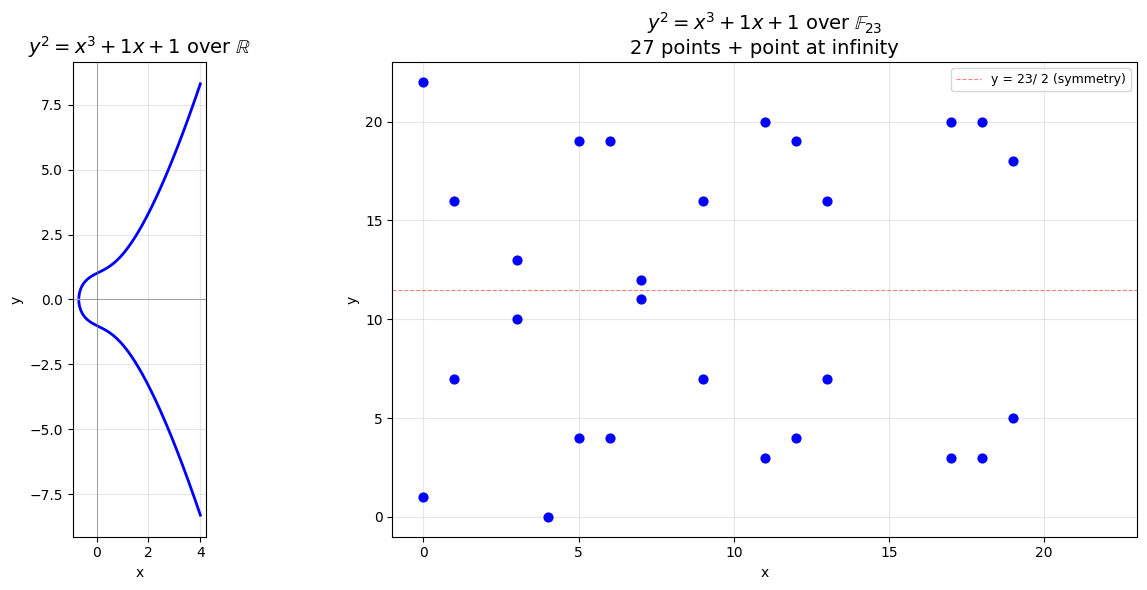


27 points on the curve (+ point at infinity = 28)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

a_small, b_small = 1, 1
p_small = 23

def is_quadratic_residue(n, p):
    if n % p == 0:
        return True
    return pow(n, (p - 1) // 2, p) == 1

def mod_sqrt_small(a, p):
    return pow(a, (p + 1) // 4, p)

points = []
for x in range(p_small):
    rhs = (x**3 + a_small * x + b_small) % p_small
    if is_quadratic_residue(rhs, p_small):
        y = mod_sqrt_small(rhs, p_small)
        points.append((x, y))
        if y != 0 and y != p_small - y:
            points.append((x, p_small - y))

points.sort()
xs_fp, ys_fp = zip(*points)

# --- Side-by-side: real curve vs finite field ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: smooth curve over the reals
x_real = np.linspace(-1.5, 4, 1000)
rhs_real = x_real**3 + a_small * x_real + b_small
mask = rhs_real >= 0
y_pos = np.sqrt(rhs_real[mask])
ax1.plot(x_real[mask], y_pos, 'b-', linewidth=2)
ax1.plot(x_real[mask], -y_pos, 'b-', linewidth=2)
ax1.axhline(0, color='gray', linewidth=0.5)
ax1.axvline(0, color='gray', linewidth=0.5)
ax1.set_title(f'$y^2 = x^3 + {a_small}x + {b_small}$ over $\\mathbb{{R}}$', fontsize=14)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)

# Right: scatter plot over F_p
ax2.scatter(xs_fp, ys_fp, c='blue', s=40, zorder=5)
ax2.set_title(f'$y^2 = x^3 + {a_small}x + {b_small}$ over $\\mathbb{{F}}_{{{p_small}}}$\n'
              f'{len(points)} points + point at infinity', fontsize=14)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_xlim(-1, p_small)
ax2.set_ylim(-1, p_small)
ax2.axhline(p_small / 2, color='red', linewidth=0.8, linestyle='--', alpha=0.5, label=f'y = {p_small}/ 2 (symmetry)')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n{len(points)} points on the curve (+ point at infinity = {len(points) + 1})")

### Observation

Notice the **vertical symmetry** — for every point $(x, y)$ there's a point $(x, p-y)$.
This is because if $y^2 \equiv c \pmod{p}$, then $(-y)^2 \equiv c \pmod{p}$ too.
The negation of a point is its vertical mirror: $-P = (x, -y)$.

---